# 02 · Refh classification and 3DEP pseudo-reference

**Research question.** What class labels does the deterministic refh classifier assign from CASALS H5 inputs alone, and how do those predictions compare with spatially transferred 3DEP labels under explicit point-index alignment?

Classification is run first without a reference. A separate call loads the transferred reference and evaluates the existing predictions. The transferred labels are pseudo-reference labels: some CASALS points have no nearby 3DEP support and are assigned class 7 by the transfer policy. They are not independent ground truth or an absolute-accuracy certification.

## Paths and parameters

The H5 and reference LAZ are explicit. A missing 3DEP transfer is an error with the command to generate it. This notebook does not discover a result by modification time or search archived outputs.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "casals_l1b").is_dir():
    raise RuntimeError("Run this notebook from the CASALS repository root.")
H5_PATH = ROOT / "data/raw/casals_l1b/casals_l1b_20241112T165718_001_02.h5"
REFERENCE_PATH = ROOT / "outputs/notebooks/02_refh_classification/reference_transfer/casals_l1b_20241112T165718_001_02.laz"
OUTPUT_ROOT = ROOT / "outputs/notebooks/02_refh_classification/classification_no_reference"
PLOT_SAMPLE = 45_000
SEED = 42
if not H5_PATH.exists():
    raise FileNotFoundError(f"Missing CASALS input: {H5_PATH}")
if not REFERENCE_PATH.exists():
    raise FileNotFoundError(
        f"Missing explicit 3DEP transferred pseudo-reference: {REFERENCE_PATH}\n"
        "Generate it with:\n"
        "python -m casals_l1b reference transfer --casals-h5 "
        "data/raw/casals_l1b/casals_l1b_20241112T165718_001_02.h5 "
        "--dep3-las data/reference/3dep/casals_l1b_20241112T165718_001_02_MD_Southeast_1_2019_EPSG6347_39a068a77804.laz "
        "--output-dir outputs/notebooks/02_refh_classification/reference_transfer"
    )
print(f"Prediction input: {H5_PATH.relative_to(ROOT)}")
print(f"Pseudo-reference: {REFERENCE_PATH.relative_to(ROOT)}")

Prediction input: data\raw\casals_l1b\casals_l1b_20241112T165718_001_02.h5
Pseudo-reference: outputs\notebooks\02_refh_classification\reference_transfer\casals_l1b_20241112T165718_001_02.laz


## H5-only prediction

The API receives the CASALS H5 and classifier configuration only. No reference labels are passed to the prediction call. The generated LAZ and run metadata record `evaluation.status = not_run`.

In [2]:
from casals_l1b.classification import DEFAULT_CONFIG, LABEL_ORDER, CLASS_NAME_MAP
from casals_l1b.classification_cli import classify_refh, build_output_paths

config = dict(DEFAULT_CONFIG)
config["OUTPUT_ROOT"] = OUTPUT_ROOT
config["WRITE_DIAGNOSTIC_PNG"] = False
config["WRITE_ERROR_FEATURE_SUMMARY"] = False
classification_result = classify_refh(H5_PATH, config)
if classification_result["status"] != "success":
    raise RuntimeError(classification_result.get("error", "classification failed"))
classification_arrays = classification_result["classification_summary_arrays"]
prediction_class = np.asarray(classification_arrays["pred_class_baseline"], dtype=np.uint8)
class_codes, class_values = np.unique(prediction_class, return_counts=True)
class_counts = {int(k): int(v) for k, v in zip(class_codes, class_values)}
classification_output = build_output_paths(OUTPUT_ROOT, H5_PATH.stem)
metadata = json.loads(Path(classification_result["metadata_path"]).read_text(encoding="utf-8"))
print("Prediction status:", classification_result["status"])
print("Evaluation metadata:", metadata["evaluation"])
print("Prediction classes:", class_counts)
print("Classified LAZ:", classification_output["classified_laz"])

Processing: casals_l1b_20241112T165718_001_02


Read CASALS points: 3,604,480


Ground support candidates: 42,740
Valid ground grid cells: 1,213


Classifier mode: rule_combined_v1
Density source: computed_internal
Rule switches: near_ground=False, signal_density=False, dtm_support=False, scanline=True, below_ground=False
Predicted class counts: {1: 290537, 2: 1346761, 7: 1967182}
Predicted class counts table
 code                   name   count
    1 processed_unclassified  290537
    2                 ground 1346761
    7                  noise 1967182
Classification reason counts
 code                             name   count
    1        ground_abs_hag_within_tol 1346761
    2                noise_invalid_dtm     196
    3               noise_below_ground  814583
    4              noise_above_max_hag 1117545
    5 processed_unclassified_valid_hag  290537
    9 noise_low_density_processed_only   34858
Density valid fraction: 1.000000
Density quantiles by predicted class
 class_code             class_name  density_p05  density_median  density_p95
          1 processed_unclassified     0.024828        0.133690     0.903363
    

Wrote: C:\Users\zhong267\OneDrive - purdue.edu\CASALS\outputs\notebooks\02_refh_classification\classification_no_reference\casals_l1b_20241112T165718_001_02\casals_l1b_20241112T165718_001_02_baseline_classified.laz
Prediction status: success
Evaluation metadata: {'status': 'not_run', 'reason': 'no_reference_provided'}
Prediction classes: {1: 290537, 2: 1346761, 7: 1967182}
Classified LAZ: C:\Users\zhong267\OneDrive - purdue.edu\CASALS\outputs\notebooks\02_refh_classification\classification_no_reference\casals_l1b_20241112T165718_001_02\casals_l1b_20241112T165718_001_02_baseline_classified.laz


## Point-index alignment and transferred-label coverage

The 3DEP transfer file carries the zero-based CASALS `point_index`, so the alignment is explicit. Alignment says which prediction row a pseudo-label refers to; it does not say that a nearby 3DEP return was available. Transfer status and confidence fields are therefore reported separately.

In [3]:
from casals_l1b.evaluation import (
    read_reference_labels, align_prediction_to_reference,
    map_reference_labels_to_baseline_classes, evaluate_classification,
)
from casals_l1b.refh import read_refh_points, project_refh_points

reference = read_reference_labels(REFERENCE_PATH)
prediction = {"point_index": np.arange(prediction_class.size, dtype=np.int64)}
alignment = align_prediction_to_reference(prediction, reference, config)
eval_mask = np.asarray(alignment["eval_match_valid"], dtype=bool)
reference_class = map_reference_labels_to_baseline_classes(alignment["eval_gt_class_raw"])
status_names = {0: "far_no_match_noise", 1: "strict_3dep_label", 2: "weak_3dep_label",
                3: "ambiguous_near_3dep", 4: "nonfinite_noise"}
status_values, status_counts = np.unique(reference["transfer_status"], return_counts=True)
status_table = pd.DataFrame([{
    "status_code": int(status), "status": status_names.get(int(status), "unknown"),
    "points": int(count), "fraction_of_CASALS": float(count / prediction_class.size),
} for status, count in zip(status_values, status_counts)])
display(status_table)
print("Alignment method:", alignment["alignment_method"])
print("Aligned rows:", int(eval_mask.sum()), "of", prediction_class.size)
print("Reference has point_index:", "point_index" in reference)
print("Finite distance records:", int(np.isfinite(reference["nearest3dep_dist_m"]).sum()))

# The default evaluation follows DEFAULT_CONFIG. A second sensitivity run excludes
# status 0, which means no nearby 3DEP support and a transfer-assigned class 7.
evaluation_default = evaluate_classification(
    prediction_class, reference_class, eval_mask,
    classification_arrays["dtm_sample_valid"],
    alignment["reference_transfer_status"],
    alignment["reference_nearest3dep_dist_m"],
    alignment["reference_class_vote_ratio"], config,
)
supported_config = {**config, "EVAL_REQUIRE_TRANSFER_STATUS": [1, 2, 3]}
evaluation_supported = evaluate_classification(
    prediction_class, reference_class, eval_mask,
    classification_arrays["dtm_sample_valid"],
    alignment["reference_transfer_status"],
    alignment["reference_nearest3dep_dist_m"],
    alignment["reference_class_vote_ratio"], supported_config,
)
summary_rows = []
for label, result in [("default evaluation rules", evaluation_default),
                      ("3DEP-supported statuses 1-3", evaluation_supported)]:
    for row in result["evaluation_summary_rows"]:
        summary_rows.append({"population": label, **row})
display(pd.DataFrame(summary_rows))

,status_code,status,points,fraction_of_CASALS
0,0,far_no_match_noise,1996088,0.553780
1,1,strict_3dep_label,1461182,0.405379
2,2,weak_3dep_label,28773,0.007983
3,3,ambiguous_near_3dep,118437,0.032858


Alignment method: point_index
Aligned rows: 3604480 of 3604480
Reference has point_index: True
Finite distance records: 1608392


,population,subset_name,n_points,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,...,support_min,support_1,support_2,support_7,true1_pred2_count,true7_pred1_count,true2_pred1_count,true2_pred7_count,true1_pred2_fraction_of_true1,true7_pred1_fraction_of_true7
0,default evaluation rules,all_matched,3604480,0.937062,0.895544,0.851647,0.867278,0.935807,0.937062,0.933758,...,395125,395125,1213267,1996088,151274,39113,15909,7048,0.382851,0.019595
1,default evaluation rules,high_confidence_reference,1450551,0.894912,0.619056,0.483755,0.519858,0.904755,0.894912,0.880366,...,270333,270333,1180218,0,144330,0,4261,1050,0.533897,NaN
2,3DEP-supported statuses 1-3,all_matched,1608392,0.886491,0.607989,0.525710,0.553444,0.899398,0.886491,0.881867,...,395125,395125,1213267,0,151274,0,15909,7048,0.382851,NaN
3,3DEP-supported statuses 1-3,high_confidence_reference,1450551,0.894912,0.619056,0.483755,0.519858,0.904755,0.894912,0.880366,...,270333,270333,1180218,0,144330,0,4261,1050,0.533897,NaN


## Prediction maps and class distributions

Maps use projected CASALS coordinates and fixed random samples. The pseudo-reference panel distinguishes records with 3DEP support from the far-no-match policy class; this prevents class 7 from being interpreted as observed 3DEP noise everywhere.

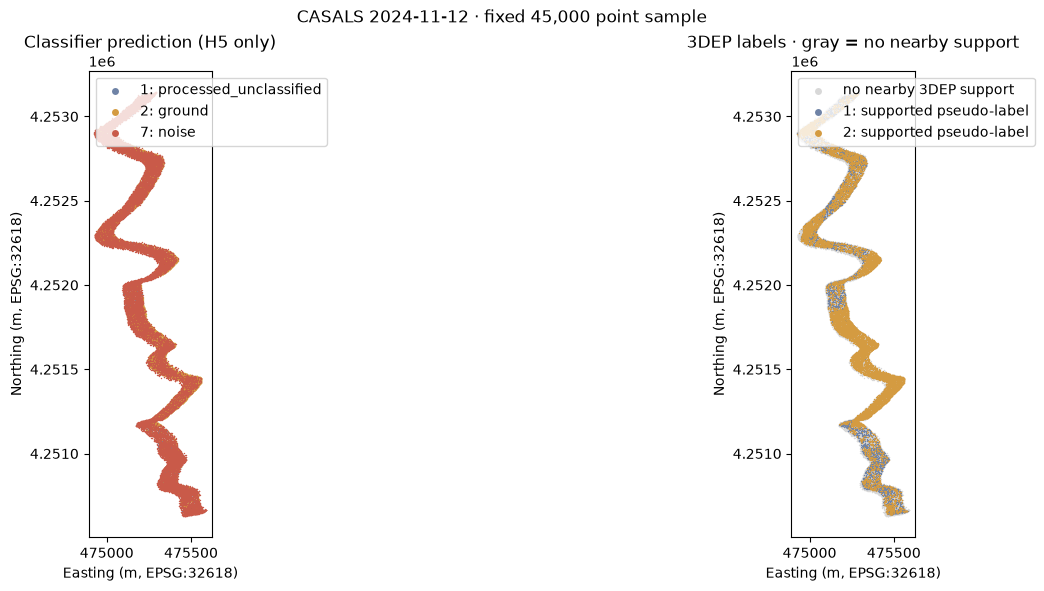

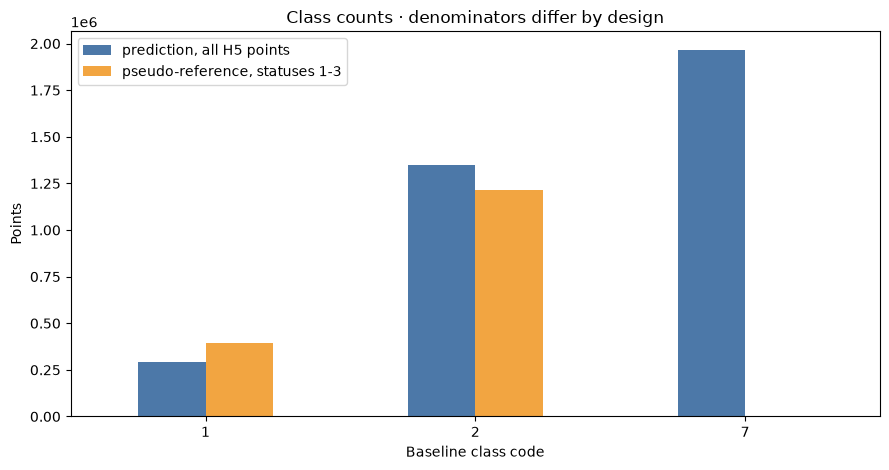

In [4]:
points = read_refh_points(H5_PATH)
projected = project_refh_points(points)
rng = np.random.default_rng(SEED)
idx = rng.choice(prediction_class.size, size=min(PLOT_SAMPLE, prediction_class.size), replace=False)
colors = {1: "#6f83a6", 2: "#d49b41", 7: "#c95a49"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)
for cls in LABEL_ORDER:
    selected = idx[prediction_class[idx] == cls]
    if selected.size:
        axes[0].scatter(projected.easting[selected], projected.northing[selected],
                        s=1, c=colors[cls], label=f"{cls}: {CLASS_NAME_MAP[cls]}",
                        linewidths=0, rasterized=True)
axes[0].set_title("Classifier prediction (H5 only)")
status_sample = alignment["reference_transfer_status"][idx]
unsupported = idx[~np.isin(status_sample, [1, 2, 3])]
if unsupported.size:
    axes[1].scatter(projected.easting[unsupported], projected.northing[unsupported],
                    s=1, c="#d8d8d8", label="no nearby 3DEP support", linewidths=0, rasterized=True)
for cls in LABEL_ORDER:
    selected = idx[np.isin(status_sample, [1, 2, 3]) & (reference_class[idx] == cls)]
    if selected.size:
        axes[1].scatter(projected.easting[selected], projected.northing[selected],
                        s=1, c=colors[cls], label=f"{cls}: supported pseudo-label",
                        linewidths=0, rasterized=True)
axes[1].set_title("3DEP labels · gray = no nearby support")
for ax in axes:
    ax.set_xlabel("Easting (m, EPSG:32618)")
    ax.set_ylabel("Northing (m, EPSG:32618)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(markerscale=5, loc="best")
fig.suptitle("CASALS 2024-11-12 · fixed 45,000 point sample")
plt.show()

pred_counts = pd.Series(prediction_class).value_counts().reindex(LABEL_ORDER, fill_value=0)
supported_ref = eval_mask & np.isin(alignment["reference_transfer_status"], [1, 2, 3])
ref_counts = pd.Series(reference_class[supported_ref]).value_counts().reindex(LABEL_ORDER, fill_value=0)
comparison = pd.DataFrame({"prediction, all H5 points": pred_counts,
                           "pseudo-reference, statuses 1-3": ref_counts})
ax = comparison.plot(kind="bar", figsize=(9, 4.8), color=["#4c78a8", "#f2a541"])
ax.set(title="Class counts · denominators differ by design", xlabel="Baseline class code",
       ylabel="Points", xticklabels=[str(v) for v in LABEL_ORDER])
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Supported-label confusion matrix and per-class results

The main confusion matrix below uses transfer statuses 1–3, so rows with no nearby 3DEP support are excluded. Ambiguous and weak labels remain in that stated population. The notebook also reports the stricter high-confidence subset produced by the configured distance and vote-ratio thresholds.

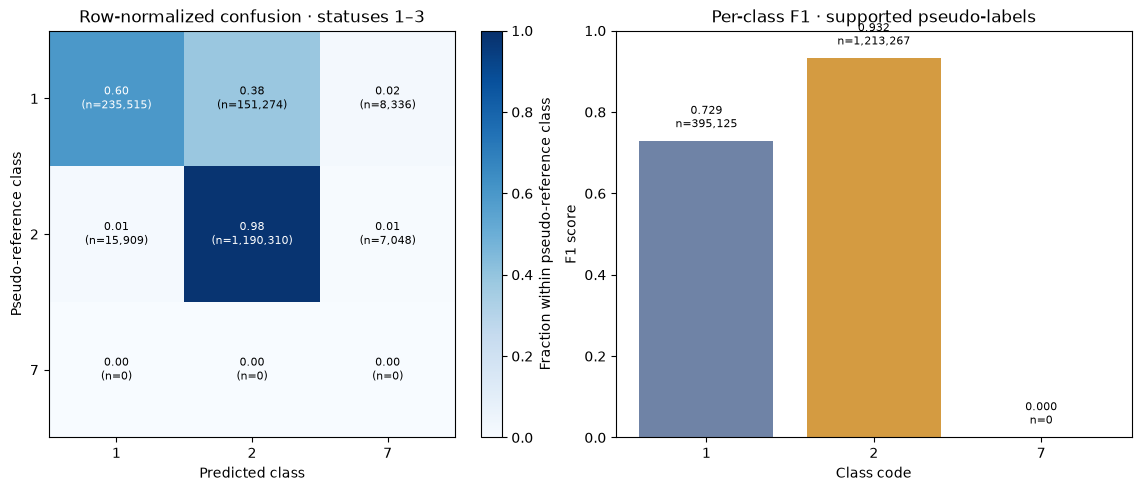

Supported-label accuracy: 0.8864909798108919
Supported-label macro-F1: 0.5534444401098599
Supported-label weighted-F1: 0.8818665283649509
High-confidence subset status / n: ok 1450551
Default all-aligned population n: 3604480


In [5]:
supported = evaluation_supported["subset_results"]["all_matched"]
cm = np.asarray(supported["confusion_matrix"], dtype=np.int64)
row_total = cm.sum(axis=1, keepdims=True)
cm_rate = np.divide(cm, row_total, out=np.zeros_like(cm, dtype=float), where=row_total > 0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
im = axes[0].imshow(cm_rate, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(3), [str(v) for v in LABEL_ORDER])
axes[0].set_yticks(range(3), [str(v) for v in LABEL_ORDER])
axes[0].set(xlabel="Predicted class", ylabel="Pseudo-reference class",
            title="Row-normalized confusion · statuses 1–3")
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{cm_rate[i,j]:.2f}\n(n={cm[i,j]:,})", ha="center", va="center",
                     color="white" if cm_rate[i,j] > .55 else "black", fontsize=8)
fig.colorbar(im, ax=axes[0], label="Fraction within pseudo-reference class")

f1 = [supported["per_class_metrics"][int(cls)]["f1"] for cls in LABEL_ORDER]
support = [supported["per_class_metrics"][int(cls)]["support"] for cls in LABEL_ORDER]
axes[1].bar([str(v) for v in LABEL_ORDER], f1, color=[colors[v] for v in LABEL_ORDER])
axes[1].set(ylim=(0, 1), xlabel="Class code", ylabel="F1 score",
            title="Per-class F1 · supported pseudo-labels")
for x, score, n in zip(range(3), f1, support):
    axes[1].text(x, score + 0.025, f"{score:.3f}\nn={n:,}", ha="center", va="bottom", fontsize=8)
plt.show()

high = evaluation_default["subset_results"].get("high_confidence_reference", {})
print("Supported-label accuracy:", supported["accuracy"])
print("Supported-label macro-F1:", supported["macro_f1"])
print("Supported-label weighted-F1:", supported["weighted_f1"])
print("High-confidence subset status / n:", high.get("status"), high.get("n_points"))
print("Default all-aligned population n:", evaluation_default["subset_results"].get("all_matched", {}).get("n_points"))

## Representative supported-label errors

Error examples are selected only among transfer statuses 1–3. They show classifier reason codes and pseudo-reference confidence fields. The sample is diagnostic; the transferred labels remain subject to the empirical height alignment and nearest-neighbor label-transfer limitations.

In [6]:
from casals_l1b.classification import CLASS_REASON_MAP
supported_mask = eval_mask & np.isin(alignment["reference_transfer_status"], [1, 2, 3])
error_idx = np.flatnonzero(supported_mask & (prediction_class != reference_class))
reason = np.asarray(classification_arrays["classification_reason"], dtype=np.uint8)
hag = np.asarray(classification_arrays["height_above_ground_m"], dtype=np.float64)
snr = np.asarray(classification_arrays["refh_snr"], dtype=np.float64)
nearest = alignment["reference_nearest3dep_dist_m"]
vote = alignment["reference_class_vote_ratio"]
if error_idx.size:
    order = np.argsort(np.nan_to_num(nearest[error_idx], nan=np.inf))
    chosen = error_idx[order[:12]]
    error_table = pd.DataFrame({
        "point_index": chosen,
        "transfer_status": [status_names[int(v)] for v in alignment["reference_transfer_status"][chosen]],
        "pseudo_reference": reference_class[chosen],
        "prediction": prediction_class[chosen],
        "prediction_reason": [CLASS_REASON_MAP.get(int(v), "unknown") for v in reason[chosen]],
        "refh_snr": snr[chosen], "height_above_ground_m": hag[chosen],
        "nearest_3dep_distance_m": nearest[chosen], "class_vote_ratio": vote[chosen],
    })
    display(error_table)
else:
    print("No errors in the explicit supported-label evaluation population.")
print(f"Supported-label errors: {error_idx.size:,} / {int(supported_mask.sum()):,} points")

,point_index,transfer_status,pseudo_reference,prediction,prediction_reason,refh_snr,height_above_ground_m,nearest_3dep_distance_m,class_vote_ratio
0,2976041,strict_3dep_label,1,2,ground_abs_hag_within_tol,2.942331,0.548726,0.005341,1.000000
1,2590058,strict_3dep_label,1,2,ground_abs_hag_within_tol,3.776055,0.177340,0.008364,0.666667
2,1755337,strict_3dep_label,2,1,processed_unclassified_valid_hag,4.313411,1.676391,0.009280,1.000000
3,2946195,strict_3dep_label,1,2,ground_abs_hag_within_tol,2.180300,0.230573,0.009520,0.750000
4,3128720,strict_3dep_label,1,2,ground_abs_hag_within_tol,2.617235,0.505399,0.011149,0.833333
5,692644,ambiguous_near_3dep,1,2,ground_abs_hag_within_tol,3.575129,0.298224,0.011358,0.500000
6,2999184,strict_3dep_label,1,2,ground_abs_hag_within_tol,3.325757,0.310108,0.013065,0.666667
7,128099,strict_3dep_label,1,2,ground_abs_hag_within_tol,5.768047,0.772288,0.013671,0.750000
8,1747536,ambiguous_near_3dep,1,2,ground_abs_hag_within_tol,3.885644,0.702271,0.014228,0.500000
9,3143085,ambiguous_near_3dep,1,2,ground_abs_hag_within_tol,2.093831,0.328217,0.014603,0.500000


Supported-label errors: 182,567 / 1,608,392 points


## Interpretation and limitations

- Prediction uses CASALS H5 only; evaluation begins after the prediction is written.
- `point_index` alignment is exact, but transfer status separately describes 3DEP support. The default evaluation includes every aligned point; its class-7 labels include the 1,996,088 far-no-match assignments. This is why a supported-status sensitivity result is shown separately.
- Statuses 1–3 still include weak or ambiguous transfers. The high-confidence subset applies the existing nearest-distance and vote-ratio thresholds; it is not independently labeled truth.
- The transfer estimates one empirical vertical shift from ground-like samples. It is not a geoid or vertical-datum transformation.
- Results compare a rule-based classifier with spatially transferred pseudo-labels. They do not certify independent classification accuracy.